<a href="https://colab.research.google.com/github/saranyav02/Computational_Pharmacology/blob/main/Neural_ODEs_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import prereqs
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

class ODEFunc(nn.Module):
    def __init__(self, hidden_dim, augment_dim=1):
        super(ODEFunc, self).__init__()
        self.augment_dim = augment_dim
        self.net = nn.Sequential(
            nn.Linear(2 + self.augment_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, 2 + self.augment_dim)
        )

    def forward(self, t, x):
        return self.net(x)

class ODESolver(nn.Module):
    def __init__(self, func, method='euler', augment_dim=1):
        super(ODESolver, self).__init__()
        self.func = func
        self.method = method
        self.augment_dim = augment_dim

    def forward(self, x0, t):
        h = t[1] - t[0]
        trajectory = [x0]
        x = x0

        for i in range(len(t) - 1):
            if self.method == 'euler':
                # Simple Euler method
                dx = self.func(t[i], x) * h
                x = x + dx
            elif self.method == 'rk4':
                # 4th-order Runge-Kutta method
                k1 = self.func(t[i], x)
                k2 = self.func(t[i] + h/2, x + h/2 * k1)
                k3 = self.func(t[i] + h/2, x + h/2 * k2)
                k4 = self.func(t[i] + h, x + h * k3)
                dx = h/6 * (k1 + 2*k2 + 2*k3 + k4)
                x = x + dx

            trajectory.append(x)

        return torch.stack(trajectory)


We first wish to test this method on synthetic data generated from a simple drug absorbtion model

  8%|▊         | 25/300 [00:00<00:03, 88.44it/s]

Epoch 10/300, Loss: 0.005761
Epoch 20/300, Loss: 0.007405
Epoch 30/300, Loss: 0.006149


 20%|██        | 60/300 [00:00<00:02, 106.76it/s]

Epoch 40/300, Loss: 0.004207
Epoch 50/300, Loss: 0.004051
Epoch 60/300, Loss: 0.004002


 27%|██▋       | 82/300 [00:00<00:02, 104.16it/s]

...

Epoch 250/300, Loss: 0.003869
Epoch 260/300, Loss: 0.003869
Epoch 270/300, Loss: 0.003868


 98%|█████████▊| 294/300 [00:02<00:00, 102.86it/s]

Epoch 280/300, Loss: 0.003868
Epoch 290/300, Loss: 0.003868


100%|██████████| 300/300 [00:02<00:00, 105.02it/s]


Epoch 300/300, Loss: 0.003867


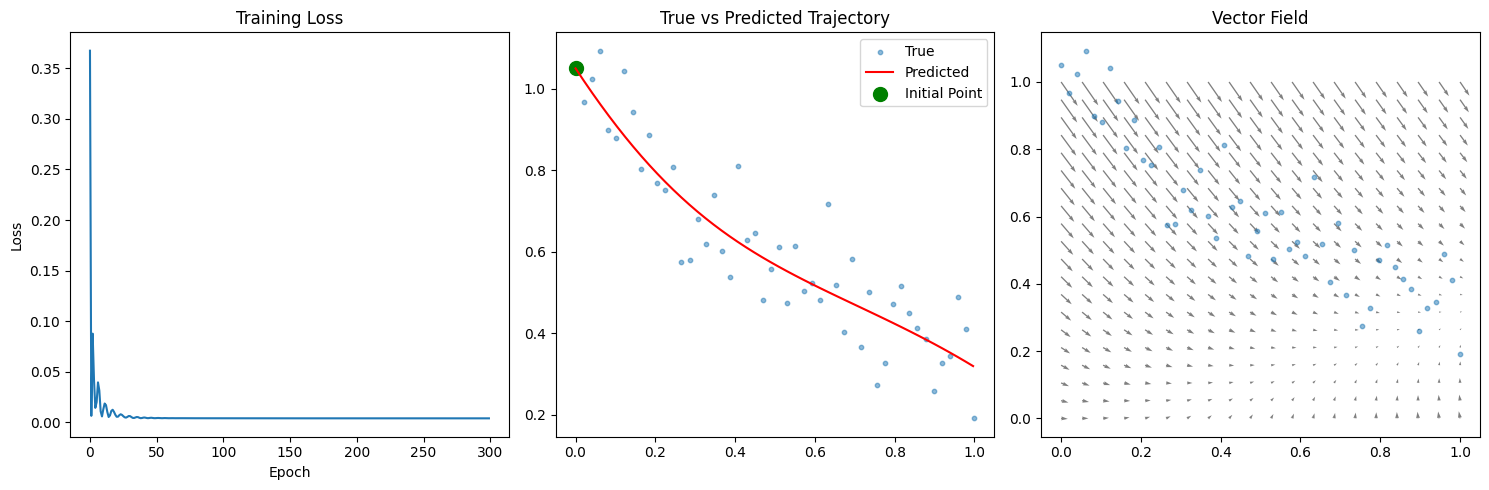

Training complete!


In [ ]:

#simple drug absorption (exponential decay)
def generate_exp_data(n_points=100, noise=0.1):
    theta = np.linspace(0, 3 * np.pi, n_points)
    t=np.linspace(0,1,n_points)
    z=math.e**(-t)+np.random.normal(0, noise, n_points)
    return np.column_stack((t,z))


#the goal is to predict data points given only initial data points
def main():
    torch.manual_seed(42)
    np.random.seed(42)
    # Number of augmented dimensions to add
    augment_dim = 1
    #generate exponential decay data
    n_points = 50
    exp_data = generate_exp_data(n_points=n_points, noise=0.1)
    exp_data = torch.tensor(exp_data, dtype=torch.float32)
    t = torch.linspace(0, 1, n_points)
    func = ODEFunc(hidden_dim=100, augment_dim=augment_dim)
    ode_solver = ODESolver(func, method='euler', augment_dim=augment_dim)

    # Initial condition (starting point of trajectory) with augmented dimensions
    x0_aug = torch.zeros(1, 2 + augment_dim, dtype=torch.float32)
    x0_aug[0, :2] = exp_data[0]  # Copy original dimensions
    x0 = x0_aug

    #optimizer for training
    optimizer = optim.Adam(func.parameters(), lr=0.01)

    # Training loop
    n_epochs = 300
    losses = []

    for epoch in tqdm(range(n_epochs)):
        optimizer.zero_grad()
        #predicted trajectory
        pred_trajectory = ode_solver(x0, t)

        # Loss is MSE between predicted and true trajectory (only for original dimensions)
        loss = nn.MSELoss()(pred_trajectory[:, :, :2].squeeze(), exp_data)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.6f}')

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')

    # Plot true vs predicted trajectories
    plt.subplot(1, 3, 2)
    pred_trajectory_np = pred_trajectory.detach().squeeze().numpy()[:, :2]
    exp_data_np = exp_data.numpy()

    plt.scatter(exp_data_np[:, 0], exp_data_np[:, 1], label='True', s=10, alpha=0.5)
    plt.plot(pred_trajectory_np[:, 0], pred_trajectory_np[:, 1], 'r-', label='Predicted')
    plt.scatter(x0.detach().numpy()[0, 0], x0.detach().numpy()[0, 1], c='g', s=100, label='Initial Point')
    plt.legend()
    plt.title('True vs Predicted Trajectory')

    # Plot vector field
    plt.subplot(1, 3, 3)

    x = np.linspace(0, 1, 20)
    y = np.linspace(0, 1, 20)
    X, Y = np.meshgrid(x, y)

    # Compute vector field
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_points_aug = np.zeros((grid_points.shape[0], 2 + augment_dim))
    grid_points_aug[:, :2] = grid_points

    grid_points_tensor = torch.tensor(grid_points_aug, dtype=torch.float32)

    with torch.no_grad():
        derivatives = func(0, grid_points_tensor).numpy()

    # We're only interested in visualizing the derivatives of the original dimensions
    U = derivatives[:, 0].reshape(X.shape)
    V = derivatives[:, 1].reshape(X.shape)

    plt.quiver(X, Y, U, V, alpha=0.5)
    plt.scatter(exp_data_np[:, 0], exp_data_np[:, 1], label='True', s=10, alpha=0.5)
    plt.title('Vector Field')


    plt.tight_layout()
    plt.show()

    print("Training complete!")

main()

We next wish to test the method on experimental data for which we do not know the "true" dynamics. We use pharmacokinetic data of the venous concentration of cocaine in Rhesus monkeys over time, presented below. Reimplement the above code to predict the trajectory of this system


In [ ]:


#experimental data (cocaine in Rhesus monkeys)
def cocaine_data():
  t=[1.7094301899366897,3.768743752082635, 5.794735088303895, 11.136287904031988,21.1562812395868, 30.999666777740753,60.833055648117295, 101.06964345218262]
  x=[16.111296234588465, 35.27157614128622, 51.532822392535806, 76.24791736087968, 67.9873375541486, 64.36187937354214, 39.86671109630121, 20.449850049983297]
  return np.column_stack((t,x))


def main_real():
    torch.manual_seed(42)
    np.random.seed(42)

    augment_dim = 2

    n_points = 8

    real_data = cocaine_data()
    real_data = torch.tensor(real_data, dtype=torch.float32)

    t = torch.linspace(0, 1, n_points)

    func = ODEFunc(hidden_dim=100, augment_dim=augment_dim)
    ode_solver = ODESolver(func, method='euler', augment_dim=augment_dim)

    # Initial condition (starting point of the spiral) with augmented dimensions
    x0_aug = torch.zeros(1, 2 + augment_dim, dtype=torch.float32)
    x0_aug[0, :2] = real_data[0]  # Copy original dimensions
    x0 = x0_aug

    optimizer = optim.Adam(func.parameters(), lr=0.01)

    # Training loop
    n_epochs = 300
    losses = []

    for epoch in tqdm(range(n_epochs)):
        optimizer.zero_grad()
        pred_trajectory = ode_solver(x0, t)

        # Loss is MSE between predicted and true trajectory (only for original dimensions)
        loss = nn.MSELoss()(pred_trajectory[:, :, :2].squeeze(), real_data)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.6f}')

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')

    # Plot true vs predicted trajectories
    plt.subplot(1, 3, 2)
    pred_trajectory_np = pred_trajectory.detach().squeeze().numpy()[:, :2]  # Only use original dimensions
    real_data_np = real_data.numpy()

    plt.scatter(real_data_np[:, 0], real_data_np[:, 1], label='True', s=10, alpha=0.5)
    plt.plot(pred_trajectory_np[:, 0], pred_trajectory_np[:, 1], 'r-', label='Predicted')
    plt.scatter(x0.detach().numpy()[0, 0], x0.detach().numpy()[0, 1], c='g', s=100, label='Initial Point')
    plt.legend()
    plt.title('True vs Predicted Trajectory')

    # Plot vector field
    plt.subplot(1, 3, 3)

    x = np.linspace(0,100, 20)
    y = np.linspace(0,100, 20)
    X, Y = np.meshgrid(x, y)

    # Compute vector field - we need to augment these points too
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_points_aug = np.zeros((grid_points.shape[0], 2 + augment_dim))
    grid_points_aug[:, :2] = grid_points  # Only set the first 2 dimensions

    grid_points_tensor = torch.tensor(grid_points_aug, dtype=torch.float32)

    with torch.no_grad():
        derivatives = func(0, grid_points_tensor).numpy()

    # We're only interested in visualizing the derivatives of the original dimensions
    U = derivatives[:, 0].reshape(X.shape)
    V = derivatives[:, 1].reshape(X.shape)

    plt.quiver(X, Y, U, V, alpha=0.5)
    plt.scatter(real_data_np[:, 0], real_data_np[:, 1], label='True', s=10, alpha=0.5)
    plt.title('Vector Field')


    plt.tight_layout()
    plt.show()

    print("Training complete!")


main_real()